# Bagging

Bagging stands for **Bootstrap Aggregating**.

It is an ensemble learning technique that combines multiple models trained on different bootstrap samples of the training dataset.

The main goal of Bagging is to:

- Reduce variance
- Improve model stability
- Reduce overfitting
- Produce more robust predictions

Bagging is especially useful for models that have high variance, such as decision trees.

## Why Do We Need Bagging?

A single machine learning model can be sensitive to the training data.

For example, a decision tree can change significantly if the training dataset changes slightly.

This means the model has high variance.

Bagging solves this problem by:

1. Creating multiple bootstrap samples
2. Training a separate model on each sample
3. Combining the predictions of all models

Instead of relying on one model, we rely on many models.

The combined prediction is usually more stable than the prediction of an individual model.

## Basic Idea

Suppose we have a training dataset:

$$
D = \{(x_1,y_1),(x_2,y_2),\dots,(x_n,y_n)\}
$$

Bagging creates multiple datasets by sampling from the original dataset **with replacement**.

For example:

$$
D_1,\ D_2,\ D_3,\dots,D_B
$$

where each dataset has approximately the same number of observations as the original dataset.

A separate model is trained on each bootstrap sample:

$$
M_1,M_2,M_3,\dots,M_B
$$

The predictions are then aggregated.

## Bootstrap Sampling

Bootstrap sampling means randomly selecting observations **with replacement**.

Suppose the original dataset contains:

$$
D = \{A,B,C,D,E\}
$$

One bootstrap sample could be:

$$
D_1 = \{A,C,C,E,B\}
$$

Another could be:

$$
D_2 = \{B,B,D,A,E\}
$$

Notice that some observations can appear multiple times while some observations may not appear at all.

This is the key idea behind Bagging.

In [1]:
import numpy as np

np.random.seed(42)

data = np.array(["A", "B", "C", "D", "E"])

bootstrap_sample = np.random.choice(
    data,
    size=len(data),
    replace=True
)

bootstrap_sample

array(['D', 'E', 'C', 'E', 'E'], dtype='<U1')

### Important Point

Bootstrap sampling uses:

$$
\text{Sampling with replacement}
$$

Therefore:

- An observation can appear multiple times
- Some observations may not appear
- Each bootstrap dataset has approximately the same size as the original dataset

## Bagging Algorithm

The Bagging algorithm can be summarized as follows.

### Step 1

Start with the original training dataset:

$$
D
$$

### Step 2

Generate $B$ bootstrap samples:

$$
D_1,D_2,\dots,D_B
$$

### Step 3

Train one model on each bootstrap sample:

$$
M_1,M_2,\dots,M_B
$$

### Step 4

Generate predictions from all models.

For a new observation $x$:

$$
M_1(x),M_2(x),\dots,M_B(x)
$$

### Step 5

Aggregate the predictions.

For classification:

$$
\hat{y} = \text{Majority Vote}
$$

For regression:

$$
\hat{y} = \frac{1}{B}\sum_{b=1}^{B}M_b(x)
$$

This process is called **Bootstrap Aggregating**, or Bagging.

## Bagging for Classification

For classification, each model produces a class prediction.

Suppose five models predict:

$$
[0,1,1,1,0]
$$

The majority class is:

$$
1
$$

Therefore, the final Bagging prediction is:

$$
\hat{y}=1
$$

Bagging uses majority voting to combine classification predictions.

## Bagging for Regression

For regression, the predictions are averaged.

Suppose five models predict:

$$
[10,12,11,13,14]
$$

The final prediction is:

$$
\hat{y}
=
\frac{10+12+11+13+14}{5}
$$

Therefore:

$$
\hat{y}=12
$$

So Bagging uses **averaging** for regression.

## Bagging and Variance Reduction

The main strength of Bagging is **variance reduction**.

Suppose each individual model has variance:

$$
\sigma^2
$$

If we average multiple approximately independent models, the variance of their average becomes smaller.

For $B$ independent models:

$$
Var(\bar{X})
=
\frac{\sigma^2}{B}
$$

Therefore, increasing the number of models can reduce variance.

In practice, Bagging models are not completely independent because they are trained from the same original dataset.

However, bootstrap sampling makes them different enough that averaging their predictions can substantially reduce variance.

This is why Bagging is particularly effective for high-variance models.

## Bagging and the Bias-Variance Tradeoff

The expected prediction error can be viewed as:

$$
Error
=
Bias^2
+
Variance
+
Irreducible\ Noise
$$

Bagging primarily targets the **variance** component.

It usually:

- Reduces variance
- Makes predictions more stable
- Can reduce overfitting
- Usually has a smaller effect on bias

This makes Bagging particularly useful for models such as deep decision trees that have high variance.

## Visual Intuition

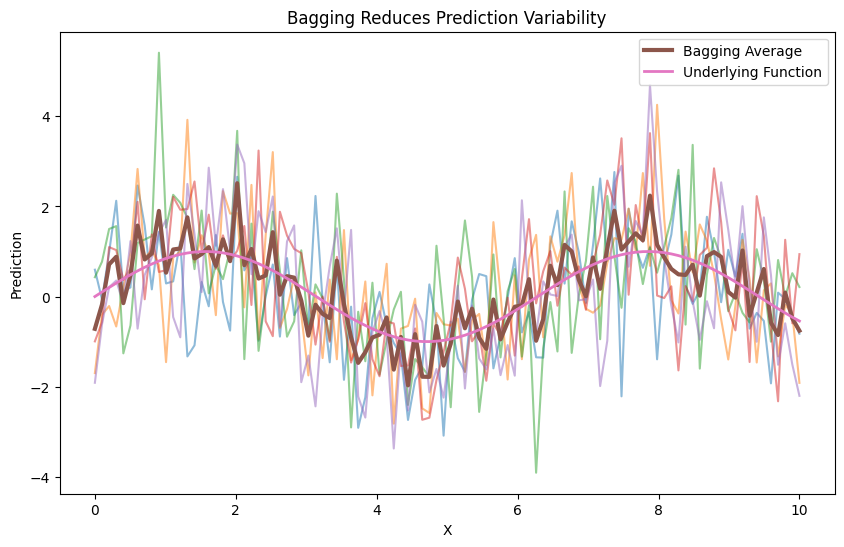

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

x = np.linspace(0, 10, 100)

individual_predictions = []

for i in range(5):
    noise = np.random.normal(0, 1.2, size=len(x))
    prediction = np.sin(x) + noise
    individual_predictions.append(prediction)

individual_predictions = np.array(individual_predictions)

bagging_prediction = individual_predictions.mean(axis=0)

plt.figure(figsize=(10, 6))

for prediction in individual_predictions:
    plt.plot(x, prediction, alpha=0.5)

plt.plot(
    x,
    bagging_prediction,
    linewidth=3,
    label="Bagging Average"
)

plt.plot(
    x,
    np.sin(x),
    linewidth=2,
    label="Underlying Function"
)

plt.xlabel("X")
plt.ylabel("Prediction")
plt.title("Bagging Reduces Prediction Variability")
plt.legend()

plt.show()

## Bagging with Decision Trees

Decision trees are often high-variance models.

A small change in the training data can produce a very different tree.

Bagging addresses this by training many decision trees on different bootstrap samples.

For example:

$$
Tree_1
\rightarrow D_1
$$

$$
Tree_2
\rightarrow D_2
$$

$$
Tree_3
\rightarrow D_3
$$

$$
\vdots
$$

$$
Tree_B
\rightarrow D_B
$$

The final prediction is obtained by aggregating all tree predictions.

This produces a much more stable model than relying on one decision tree.

## Dataset

In [3]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((800, 10), (200, 10))

## Single Decision Tree

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree = DecisionTreeClassifier(
    random_state=42
)

tree.fit(X_train, y_train)

tree_predictions = tree.predict(X_test)

tree_accuracy = accuracy_score(
    y_test,
    tree_predictions
)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.825


## BaggingClassifier

Scikit-learn provides:

`BaggingClassifier`

It trains multiple base estimators using bootstrap samples and combines their predictions.

Important parameters include:

- `estimator`
- `n_estimators`
- `max_samples`
- `max_features`
- `bootstrap`
- `bootstrap_features`
- `oob_score`
- `random_state`

In [5]:
from sklearn.ensemble import BaggingClassifier

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    max_samples=1.0,
    max_features=1.0,
    bootstrap=True,
    random_state=42
)

bagging_model.fit(X_train, y_train)

bagging_predictions = bagging_model.predict(X_test)

bagging_accuracy = accuracy_score(
    y_test,
    bagging_predictions
)

print("Bagging Accuracy:", bagging_accuracy)

Bagging Accuracy: 0.885


## Compare Decision Tree and Bagging

In [6]:
print("Decision Tree Accuracy:", tree_accuracy)
print("Bagging Accuracy:", bagging_accuracy)

Decision Tree Accuracy: 0.825
Bagging Accuracy: 0.885


## Interpretation

A single decision tree can have high variance.

Bagging trains many different trees and aggregates their predictions.

Therefore, Bagging often produces:

- More stable predictions
- Better generalization
- Lower variance
- Less sensitivity to individual training observations

The exact improvement depends on the dataset.

## Effect of Number of Estimators

The parameter:

`n_estimators`

controls the number of base models.

For example:

$$
B \in \{1,5,10,25,50,100,200\}
$$

Increasing the number of estimators generally makes the ensemble more stable.

However, after a certain point, additional models provide diminishing returns.

More estimators also increase:

- Training time
- Prediction time
- Memory usage

In [7]:
from sklearn.metrics import accuracy_score

n_estimators_values = [1, 5, 10, 25, 50, 100, 200]

accuracies = []

for n in n_estimators_values:
    model = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    accuracies.append(accuracy)

accuracies

[0.85, 0.885, 0.875, 0.875, 0.89, 0.885, 0.895]

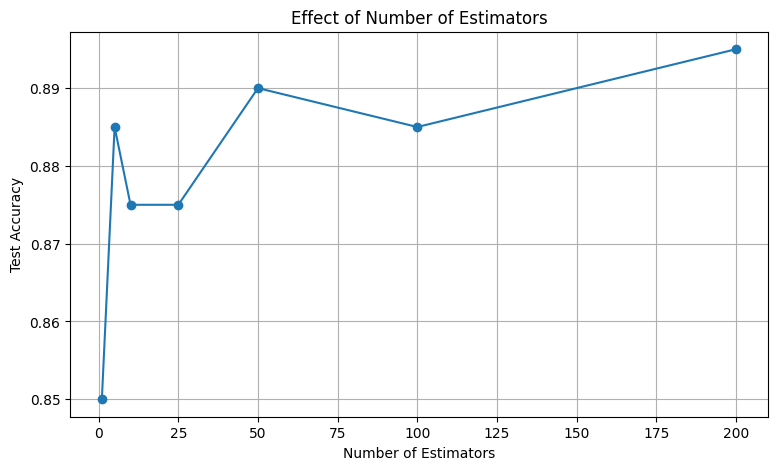

In [8]:
plt.figure(figsize=(9, 5))

plt.plot(
    n_estimators_values,
    accuracies,
    marker="o"
)

plt.xlabel("Number of Estimators")
plt.ylabel("Test Accuracy")
plt.title("Effect of Number of Estimators")

plt.grid(True)

plt.show()

## Out-of-Bag (OOB) Evaluation

Bootstrap sampling selects observations with replacement.

Because of this, some observations are not selected for a particular bootstrap sample.

These unused observations are called **Out-of-Bag (OOB) samples**.

For each model, the OOB observations can be used to evaluate that model.

Therefore, Bagging can estimate generalization performance without requiring a separate validation set.

This is called **OOB evaluation**.

## Why Do OOB Samples Exist?

Suppose the training dataset contains $n$ observations.

During bootstrap sampling, $n$ observations are selected with replacement.

The probability that a particular observation is not selected in one draw is:

$$
1-\frac{1}{n}
$$

After $n$ draws:

$$
P(\text{not selected})
=
\left(1-\frac{1}{n}\right)^n
$$

As $n$ becomes large:

$$
\left(1-\frac{1}{n}\right)^n
\rightarrow e^{-1}
$$

Therefore:

$$
e^{-1}\approx0.368
$$

Approximately **36.8% of observations are OOB for a particular bootstrap sample**.

This is an important property of Bagging.

## OOB Score in Scikit-learn

In [9]:
oob_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    bootstrap=True,
    oob_score=True,
    random_state=42
)

oob_model.fit(X_train, y_train)

print("OOB Score:", oob_model.oob_score_)
print("Test Accuracy:", oob_model.score(X_test, y_test))

OOB Score: 0.8975
Test Accuracy: 0.885


## OOB Score vs Test Score

The OOB score provides an internal estimate of generalization performance.

It is useful because:

- No separate validation set is required
- It uses observations not used by individual bootstrap models
- It provides a convenient model evaluation estimate

However, the final evaluation should still be performed on an independent test set when possible.

# Bagging for Regression

Bagging can also be used for regression.

Scikit-learn provides:

`BaggingRegressor`

Instead of majority voting, predictions are averaged.

The final prediction is:

$$
\hat{y}
=
\frac{1}{B}
\sum_{b=1}^{B}
M_b(x)
$$

In [10]:
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

X_reg, y_reg = make_regression(
    n_samples=1000,
    n_features=8,
    n_informative=6,
    noise=15,
    random_state=42
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [11]:
regressor = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=100,
    random_state=42
)

regressor.fit(
    X_train_reg,
    y_train_reg
)

reg_predictions = regressor.predict(
    X_test_reg
)

mse = mean_squared_error(
    y_test_reg,
    reg_predictions
)

r2 = r2_score(
    y_test_reg,
    reg_predictions
)

print("MSE:", mse)
print("R² Score:", r2)

MSE: 2879.7274930530602
R² Score: 0.8745010064181323


# Important Parameters

## 1. n_estimators

Number of base models.

```text
n_estimators=100

More estimators generally improve stability but increase computational cost.

## 2. max_samples

Controls how many samples are used to train each base estimator.

```text
For example:

max_samples=0.8

means each estimator receives 80% of the training samples.

## 3. max_features

Controls how many features are used by each base estimator.

```text
For example:

max_features=0.8

means each estimator uses 80% of the available features.

## 4. bootstrap

```text
Controls whether samples are drawn with replacement.

bootstrap=True

is the standard Bagging approach.

## 5. bootstrap_features

Controls whether features are sampled with replacement.

## 6. oob_score

```text
Enables Out-of-Bag evaluation.

oob_score=True

requires bootstrap sampling.

## 7. estimator

Specifies the base model.

```text
Examples include:

Decision Tree
SVM
KNN
Other estimators that support the required interface


---

## Base Estimator

Bagging is an ensemble framework.

The individual models inside the ensemble are called **base estimators**.

For example:

$$
Bagging
+
Decision\ Trees
\rightarrow
Bagged\ Decision\ Trees
$$

The base estimator does not have to be a decision tree.

Different base models can be used depending on the problem.

However, Bagging is especially effective with high-variance models.

## Feature Sampling

Bagging can also introduce randomness by selecting subsets of features.

Suppose we have:

$$
10
$$

features.

Each base model might receive only:

$$
7
$$

features.

This creates additional diversity among the models.

Therefore Bagging can introduce randomness through:

1. Sample selection
2. Feature selection

Feature sampling can be controlled using:

`max_features`

and

`bootstrap_features`.

# Bagging vs Random Forest

Random Forest is closely related to Bagging.

Both methods:

- Train multiple decision trees
- Use randomness
- Combine predictions
- Reduce variance

The major difference is how features are selected.

### Bagging

Each tree can generally use the full feature set.

Randomness primarily comes from bootstrap samples.

### Random Forest

Random Forest uses:

- Bootstrap samples
- Random subsets of features at each split

Therefore, Random Forest introduces more diversity between trees.

Conceptually:

$$
Random\ Forest
=
Bagged\ Decision\ Trees
+
Random\ Feature\ Selection
$$

# Bagging vs Boosting

Bagging and Boosting are both ensemble learning techniques, but they work differently.

| Bagging | Boosting |
|---|---|
| Models are trained independently | Models are trained sequentially |
| Focuses mainly on reducing variance | Often focuses on reducing bias |
| Uses bootstrap samples | Models focus on previous errors |
| Models can be trained in parallel | Training is generally sequential |
| More robust to noisy data | Can be sensitive to noisy data |
| Example: Random Forest | Examples: AdaBoost, Gradient Boosting |

### Bagging

$$
M_1,\ M_2,\ M_3,\dots,M_B
$$

are trained independently.

### Boosting

$$
M_1
\rightarrow
M_2
\rightarrow
M_3
\rightarrow
\dots
$$

Each new model depends on previous models.

# Advantages of Bagging

### 1. Reduces Variance

Bagging averages multiple models and therefore reduces prediction variability.

### 2. Helps Prevent Overfitting

It can reduce the tendency of high-variance models to overfit.

### 3. Improves Stability

The final model is less sensitive to changes in the training data.

### 4. Easy to Parallelize

Base estimators can generally be trained independently.

### 5. Works Well with Decision Trees

Decision trees are high-variance models, making them strong candidates for Bagging.

### 6. OOB Evaluation

Bagging can provide an internal evaluation estimate using OOB samples.

### 7. Flexible

Different types of base estimators can be used.

# Disadvantages of Bagging

### 1. Increased Computational Cost

Training many models requires more computational resources.

### 2. Increased Memory Usage

Multiple models must be stored.

### 3. Does Not Always Improve Performance

If the base model already has low variance, Bagging may provide little benefit.

### 4. Mainly Reduces Variance

Bagging is not primarily designed to reduce bias.

### 5. Less Interpretable

The final ensemble is harder to interpret than a single model.

### 6. More Complex

The final prediction depends on many individual models rather than one simple model.

# When Should You Use Bagging?

Bagging is a good choice when:

- The base model has high variance
- The model is sensitive to the training dataset
- Overfitting is a problem
- You want more stable predictions
- You have enough computational resources
- Decision trees are performing inconsistently

Typical applications include:

- Classification
- Regression
- Decision tree ensembles
- Large tabular datasets
- Problems where variance reduction is important

# When Bagging May Not Be Ideal

Bagging may not be the best choice when:

- The base model has very high bias
- The dataset is extremely small
- Interpretability is the main requirement
- Computational resources are limited
- A simpler model already performs well

In such cases, other approaches may be more appropriate.

## Complete Example

In [12]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report

X, y = make_classification(
    n_samples=1500,
    n_features=12,
    n_informative=7,
    n_redundant=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    n_estimators=100,
    max_samples=1.0,
    max_features=1.0,
    bootstrap=True,
    oob_score=True,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

predictions = model.predict(
    X_test
)

print("Test Accuracy:", accuracy_score(y_test, predictions))
print("OOB Score:", model.oob_score_)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions
    )
)

Test Accuracy: 0.9266666666666666
OOB Score: 0.8791666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93       149
           1       0.92      0.93      0.93       151

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300



## Final Conceptual Visualization

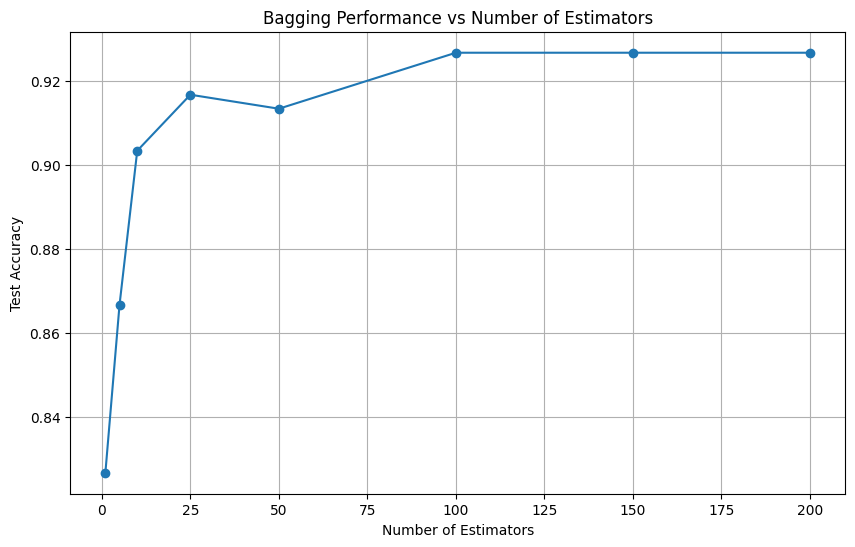

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

n_estimators_values = [1, 5, 10, 25, 50, 100, 150, 200]

tree_scores = []
bagging_scores = []

for n in n_estimators_values:

    model = BaggingClassifier(
        estimator=DecisionTreeClassifier(
            random_state=42
        ),
        n_estimators=n,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    score = model.score(
        X_test,
        y_test
    )

    bagging_scores.append(score)

plt.figure(figsize=(10, 6))

plt.plot(
    n_estimators_values,
    bagging_scores,
    marker="o"
)

plt.xlabel("Number of Estimators")
plt.ylabel("Test Accuracy")
plt.title("Bagging Performance vs Number of Estimators")

plt.grid(True)

plt.show()

# Summary

Bagging stands for:

$$
\boxed{\text{Bootstrap Aggregating}}
$$

The main steps are:

$$
Original\ Dataset
$$

$$
\downarrow
$$

$$
Bootstrap\ Samples
$$

$$
\downarrow
$$

$$
Multiple\ Base\ Models
$$

$$
\downarrow
$$

$$
Aggregation
$$

$$
\downarrow
$$

$$
Final\ Prediction
$$

For classification:

$$
Final\ Prediction
=
Majority\ Vote
$$

For regression:

$$
Final\ Prediction
=
Average
$$

The key purpose of Bagging is:

$$
\boxed{\text{Reduce Variance}}
$$

Important concepts:

- Bootstrap sampling
- Aggregation
- Variance reduction
- Base estimators
- OOB samples
- OOB score
- `BaggingClassifier`
- `BaggingRegressor`
- Random Forest
- Bagging vs Boosting

The most important intuition is:

> Instead of trusting one high-variance model, train many slightly different models and combine their predictions to obtain a more stable result.

# Key Takeaways

1. Bagging means **Bootstrap Aggregating**.

2. Bootstrap samples are created using sampling with replacement.

3. A separate base model is trained on each bootstrap sample.

4. Classification uses majority voting.

5. Regression uses averaging.

6. Bagging primarily reduces variance.

7. Bagging works particularly well with high-variance models such as decision trees.

8. OOB samples can be used for internal model evaluation.

9. Random Forest extends the Bagging idea by adding random feature selection.

10. Bagging trains models independently, while Boosting trains models sequentially.

11. Increasing `n_estimators` generally improves stability, but eventually gives diminishing returns.

12. Bagging is one of the fundamental ideas behind modern ensemble learning.